In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ASUS\Desktop\Sales Performance Analysis Dashboard\data\Superstore.csv", encoding="latin1")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [171]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
df.drop_duplicates(inplace=True)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [177]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

df = df.dropna(subset=['Order Date', 'Ship Date'])

In [180]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()


df['Profit Margin'] = df['Profit'] / df['Sales']


In [182]:
print("📌 Dataset Shape:", df.shape)
print("\n📊 Summary Statistics:")
df.describe()


📌 Dataset Shape: (9994, 24)

📊 Summary Statistics:


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Profit Margin
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.38,229.86,3.79,0.16,28.66,2015.72,0.12
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.00,0.44,1.00,0.00,-6599.98,2014.00,-2.75
25%,2499.25,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.00,17.28,2.00,0.00,1.73,2015.00,0.07
50%,4997.50,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.50,54.49,3.00,0.20,8.67,2016.00,0.27
75%,7495.75,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.00,209.94,5.00,0.20,29.36,2017.00,0.36
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,22638.48,14.00,0.80,8399.98,2017.00,0.50
std,2885.16,NaN,NaN,32063.69,623.25,2.23,0.21,234.26,1.12,0.47


Category
Technology        836154.03
Furniture         741999.80
Office Supplies   719047.03
Name: Sales, dtype: float64


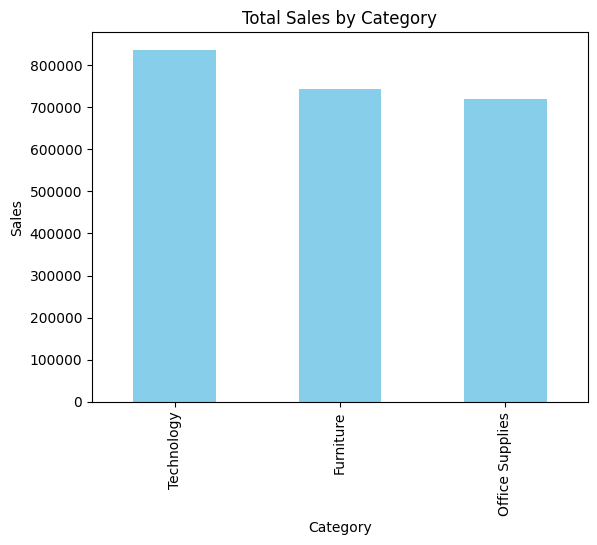

In [183]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

category_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()


Region
West      725457.82
East      678781.24
Central   501239.89
South     391721.91
Name: Sales, dtype: float64


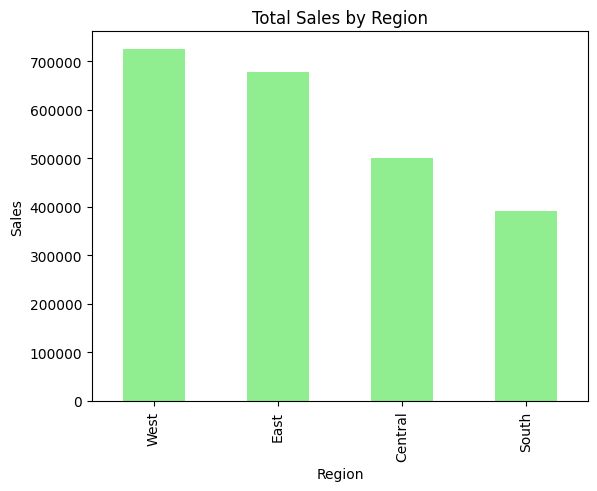

In [185]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

region_sales.plot(kind='bar', color='lightgreen')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()


Sub-Category
Copiers        55617.82
Phones         44515.73
Accessories    41936.64
Paper          34053.57
Binders        30221.76
Chairs         26590.17
Storage        21278.83
Appliances     18138.01
Furnishings    13059.14
Envelopes       6964.18
Art             6527.79
Labels          5546.25
Machines        3384.76
Fasteners        949.52
Supplies       -1189.10
Bookcases      -3472.56
Tables        -17725.48
Name: Profit, dtype: float64


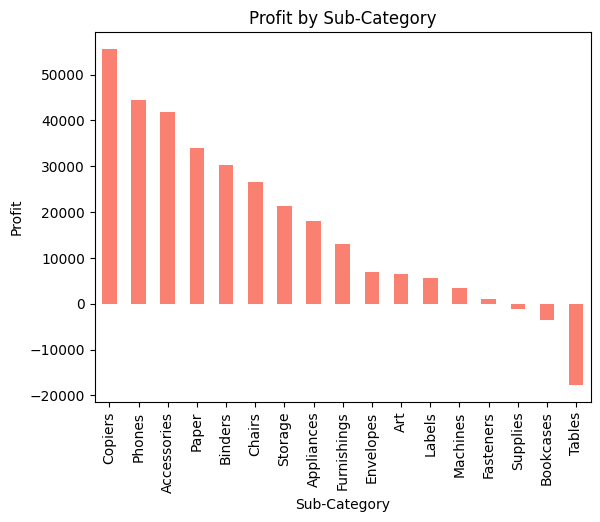

In [186]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(subcat_profit)

subcat_profit.plot(kind='bar', color='salmon')
plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.show()


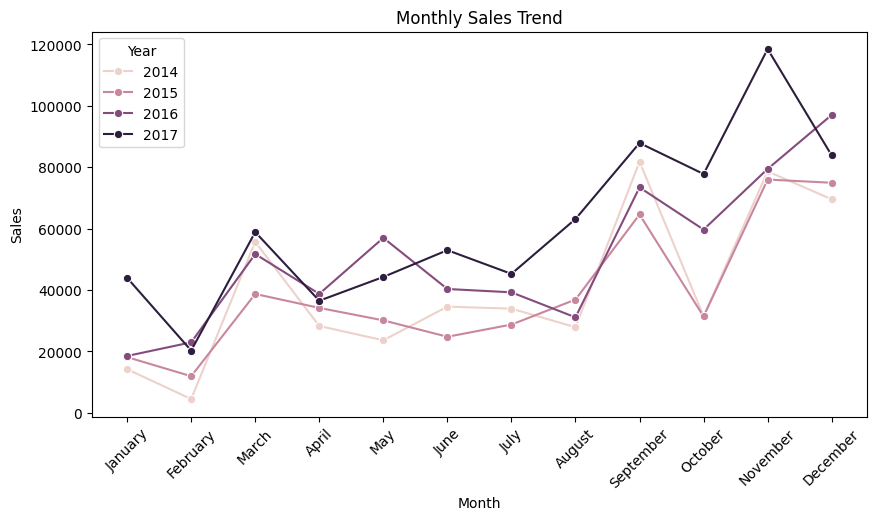

In [187]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Sort months properly
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'], categories=month_order, ordered=True)

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()


In [191]:
df.to_csv(r"C:\Users\ASUS\Desktop\Sales Performance Analysis Dashboard\data\Superstore_Cleaned.csv", index=False)
print("✅ Cleaned dataset saved as 'Superstore_Cleaned.csv'")


✅ Cleaned dataset saved as 'Superstore_Cleaned.csv'
